# Week 1 Internship Task
# Data Acquisition, Cleaning, and Exploratory Data Analysis

**Project:** Iris Dataset — Data Preparation and EDA  
**Author:** Vikas Yadav  
**Repository:** `https://github.com/Vikas-Yadav-6696/week1-iris-data-analysis`

---

## Project Overview

This notebook documents the complete Week 1 data-science workflow for the internship task **“Data Acquisition, Cleaning, and Exploratory Analysis.”**

The objective is to simulate the preparation of a public dataset for a data-science project. The work covers:

- Public dataset acquisition
- Dataset understanding and inspection
- Data-quality assessment
- Missing-value handling
- Duplicate detection and removal
- Data-type preprocessing
- Exploratory data analysis
- Summary statistics
- Multiple visualizations
- Interpretation of patterns
- Documentation of cleaning decisions
- Preparation for future machine-learning analysis

The Iris dataset was selected because it is publicly available, compact, well documented, and appropriate for demonstrating the complete data-preparation lifecycle.


# 1. Internship Task Requirements

The Week 1 task requires a practical simulation of data preparation for a data-science project.

### Required work

1. Acquire a publicly available dataset from the internet.
2. Clean and preprocess the dataset using Python.
3. Perform exploratory data analysis (EDA).
4. Explain the rationale behind cleaning decisions.
5. Provide detailed code or pseudocode.
6. Include at least three useful visualizations.
7. Highlight trends, missing values, distributions, or correlations.
8. Provide brief analytical insights.
9. Include summary statistics.
10. Discuss observed patterns and possible further analysis.
11. Present the work with clear headings and organized documentation.
12. Produce a final documented deliverable suitable for internship submission.

### Expected tools

The project uses Python with common data-science libraries:

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn


# 2. Project Planning and Dataset Selection

## Why the Iris dataset?

The Iris dataset was selected for the following practical reasons:

- It is publicly available.
- It has a clear and well-defined structure.
- It contains numerical variables suitable for statistical analysis.
- It contains a categorical target variable.
- It is small enough to inspect thoroughly.
- It provides meaningful relationships for visualization.
- It can naturally lead into a classification problem.

The original dataset contains **150 observations**, **four numerical measurement variables**, and **three species classes**.

## Important methodological note

The original Iris benchmark dataset is already relatively clean. Because this internship task specifically requires demonstrating data cleaning, a controlled working copy is created in this notebook.

Five numerical cells are intentionally changed to missing values, and three duplicate rows are added. These modifications are used **only to demonstrate a reproducible cleaning workflow**. The original source dataset is not altered.


# 3. Dataset Source

The dataset comes from the **UCI Machine Learning Repository — Iris Dataset**.

**Official source:**  
https://archive.ics.uci.edu/dataset/53/iris

The Iris dataset contains:

| Component | Description |
|---|---|
| Observations | 150 |
| Numerical features | 4 |
| Target classes | 3 |
| Target | Iris species |
| Measurement unit | Centimetres |

### Features

- Sepal length
- Sepal width
- Petal length
- Petal width

### Classes

- Setosa
- Versicolor
- Virginica


# 4. Project Workflow

The complete workflow followed in this notebook is:

**Dataset acquisition → Initial inspection → Data-quality simulation → Missing-value analysis → Duplicate detection → Cleaning → Validation → Summary statistics → EDA → Visualization → Insights → Export → Future analysis**

This structure makes the process reproducible and separates data preparation from interpretation.


In [1]:
# Optional installation command for a new environment:
# %pip install pandas numpy matplotlib seaborn scikit-learn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


# 5. Data Acquisition

For reproducibility, this notebook uses the Iris dataset available through scikit-learn. This is a programmatic representation of the same classic Iris dataset used in the UCI repository.

Using a programmatic loader avoids manually copying records and makes the analysis reproducible.


In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width",
    ],
)

df["species"] = pd.Categorical.from_codes(
    iris.target,
    iris.target_names
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())


Dataset loaded successfully.
Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# 6. Initial Dataset Inspection

Before changing any data, the first step is to understand its structure.

The following checks answer:

- How many rows and columns exist?
- What data types are present?
- Are there missing values?
- Are duplicate rows present?
- What are the basic numerical statistics?


In [3]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe(include="all"))


Dataset shape:
(150, 5)

Column names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Data types:


sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
species         category
dtype: object


Missing values:


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


Duplicate rows:
1

Summary statistics:


,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


# 7. Data Quality Simulation

Because the original benchmark dataset is clean, controlled quality issues are introduced into a working copy.

### Simulated issues

- 5 numerical cells are changed to `NaN`.
- 3 exact duplicate rows are appended.

This allows the notebook to demonstrate the same cleaning operations used by the accompanying `src/week1_eda.py` script.

The source dataframe `df` remains unchanged.

**Duplicate-count note:** the bundled Iris representation already contains one repeated record. Therefore, after adding three additional duplicate rows, `duplicated().sum()` reports **4 duplicate rows** before cleaning. This is expected and is explicitly documented rather than treated as an error.


In [4]:
work_df = df.copy()

# Five controlled missing values (same positions used by src/week1_eda.py).
missing_positions = {
    ("sepal_length", 5),
    ("sepal_width", 35),
    ("petal_length", 75),
    ("petal_width", 105),
    ("sepal_length", 125),
}

for column, row_idx in missing_positions:
    work_df.loc[row_idx, column] = np.nan

# Add three duplicate records (same rows used by src/week1_eda.py).
work_df = pd.concat(
    [work_df, work_df.iloc[[10, 60, 120]]],
    ignore_index=True
)

print("Original shape:", df.shape)
print("Working shape:", work_df.shape)
print("Total missing cells:", int(work_df.isna().sum().sum()))
print("Duplicate rows detected:", int(work_df.duplicated().sum()))

display(work_df.head())


Original shape: (150, 5)
Working shape: (153, 5)
Total missing cells: 5
Duplicate rows detected: 4


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Duplicate-count clarification

The notebook explicitly adds three duplicate rows. The Iris representation loaded through scikit-learn also contains one repeated record, so the complete working copy reports **4 duplicate rows** through `duplicated().sum()`.

This illustrates an important data-quality point: the number of duplicates detected by a data-quality check does not necessarily equal the number of duplicates intentionally introduced.


# 8. Cleaning Strategy and Rationale

## 8.1 Missing numerical values

The missing numerical values are handled using **median imputation**.

### Why median?

Median imputation:

- preserves the number of observations,
- is simple and reproducible,
- is less sensitive to extreme values than mean imputation,
- is appropriate for this demonstration dataset.

For a production project, the imputation strategy should be selected after examining the data-generating process and missingness mechanism.

## 8.2 Duplicate records

Exact duplicate rows are removed because repeated identical observations can distort descriptive statistics and downstream modeling.

## 8.3 Data types

Numerical measurements are explicitly converted to numeric values. The species column is converted to a categorical type.

## 8.4 Validation

After cleaning, the dataset is checked again for:

- remaining missing values,
- remaining duplicates,
- correct data types,
- expected shape.


# 9. Missing-Value Analysis Before Cleaning

Missing values by column:


,missing_count
sepal_length,2
sepal_width,1
petal_length,1
petal_width,1
species,0


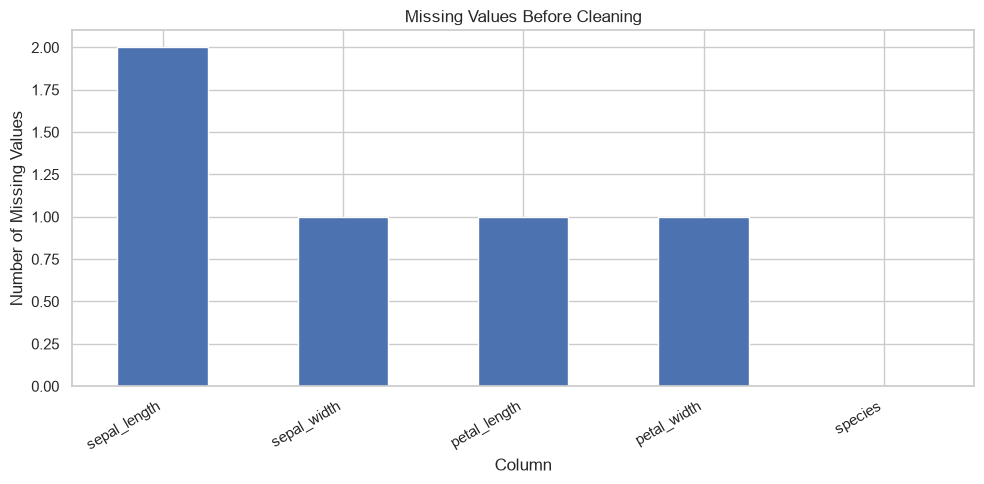

In [5]:
missing_before = work_df.isna().sum()

print("Missing values by column:")
display(missing_before.to_frame("missing_count"))

plt.figure(figsize=(10, 5))
missing_before.plot(kind="bar")
plt.title("Missing Values Before Cleaning")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Interpretation

The visualization makes the simulated data-quality problem visible before any cleaning is performed. The five missing cells are distributed across the numerical measurement columns.


# 10. Duplicate Analysis Before Cleaning

In [6]:
duplicate_count = work_df.duplicated().sum()

print(f"Duplicate rows detected: {duplicate_count}")

if duplicate_count > 0:
    display(work_df[work_df.duplicated(keep=False)].sort_values(
        by=["species", "sepal_length", "sepal_width"]
    ).head(20))


Duplicate rows detected: 4


,sepal_length,sepal_width,petal_length,petal_width,species
10,5.4,3.7,1.5,0.2,setosa
150,5.4,3.7,1.5,0.2,setosa
60,5.0,2.0,3.5,1.0,versicolor
151,5.0,2.0,3.5,1.0,versicolor
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica
120,6.9,3.2,5.7,2.3,virginica
152,6.9,3.2,5.7,2.3,virginica


# 11. Execute Cleaning and Preprocessing

In [7]:
clean_df = work_df.copy()

numeric_cols = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
]

# Convert numerical columns explicitly to numeric.
clean_df[numeric_cols] = clean_df[numeric_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

# Median imputation.
for column in numeric_cols:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].median()
    )

# Remove exact duplicate rows.
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

# Store species as categorical data.
clean_df["species"] = clean_df["species"].astype("category")

print("Cleaning completed.")
print("Cleaned shape:", clean_df.shape)


Cleaning completed.
Cleaned shape: (149, 5)


# 12. Validate the Cleaned Dataset

In [8]:
print("Remaining missing values:")
display(clean_df.isna().sum())

print("Remaining duplicate rows:")
print(clean_df.duplicated().sum())

print("\nData types after cleaning:")
display(clean_df.dtypes)

print("\nFinal shape:")
print(clean_df.shape)

assert clean_df.isna().sum().sum() == 0
assert clean_df.duplicated().sum() == 0

print("\nValidation checks passed.")


Remaining missing values:


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Remaining duplicate rows:
0

Data types after cleaning:


sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
species         category
dtype: object


Final shape:
(149, 5)

Validation checks passed.


# 13. Before-and-After Cleaning Comparison

,Before Cleaning,After Cleaning
sepal_length,2,0
sepal_width,1,0
petal_length,1,0
petal_width,1,0
species,0,0


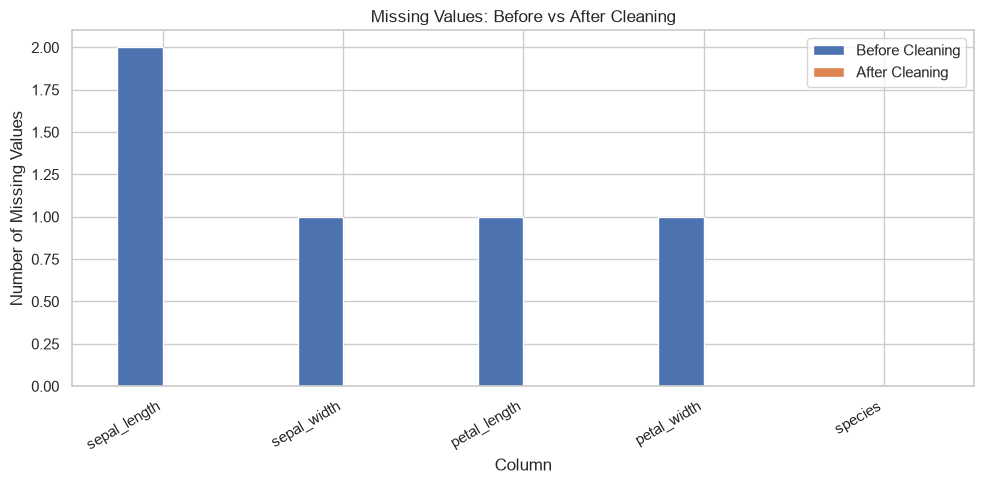

In [9]:
missing_after = clean_df.isna().sum()

comparison = pd.DataFrame({
    "Before Cleaning": missing_before,
    "After Cleaning": missing_after
})

display(comparison)

ax = comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Missing Values: Before vs After Cleaning")
ax.set_xlabel("Column")
ax.set_ylabel("Number of Missing Values")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Cleaning result

The controlled missing values have been removed through median imputation, and exact duplicate records have been removed.

The final dataset contains:

- **149 rows**
- **5 columns**
- **0 missing cells**
- **0 duplicate rows**


# 14. Summary Statistics

In [10]:
summary_stats = clean_df[numeric_cols].describe().T

summary_stats


,count,mean,std,min,25%,50%,75%,max
sepal_length,149.0,5.836913,0.822517,4.3,5.1,5.8,6.4,7.9
sepal_width,149.0,3.058389,0.436215,2.0,2.8,3.0,3.3,4.4
petal_length,149.0,3.748322,1.767561,1.0,1.6,4.3,5.1,6.9
petal_width,149.0,1.189262,0.759013,0.1,0.3,1.3,1.8,2.5


### Additional class statistics

In [11]:
class_counts = (
    clean_df["species"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

display(class_counts)

print("Class proportions:")
display(
    (clean_df["species"].value_counts(normalize=True)
     .sort_index()
     .mul(100)
     .round(2)
     .to_frame("percentage"))
)


,count
species,
setosa,50
versicolor,50
virginica,49


Class proportions:


,percentage
species,
setosa,33.56
versicolor,33.56
virginica,32.89


# 15. Exploratory Data Analysis

The EDA focuses on four questions:

1. Are the species classes reasonably balanced?
2. Which measurements show visible separation between species?
3. Which numerical variables are strongly correlated?
4. What patterns should be considered before machine-learning modeling?


# 16. Visualization 1 — Species Distribution

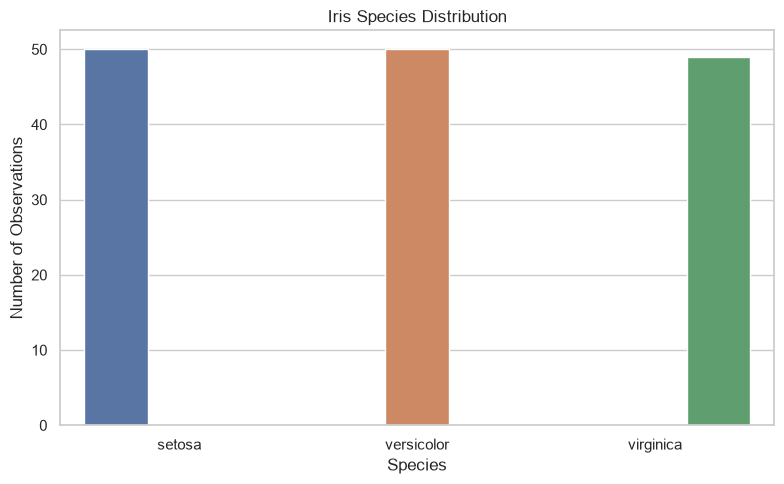

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x="species",
    hue="species",
    legend=False
)

plt.title("Iris Species Distribution")
plt.xlabel("Species")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()


### Insight

The species classes are approximately balanced. This reduces the concern that one class overwhelmingly dominates the exploratory dataset.

For future modeling, class balance should still be checked after any train/test split.


# 17. Visualization 2 — Petal Length vs Petal Width

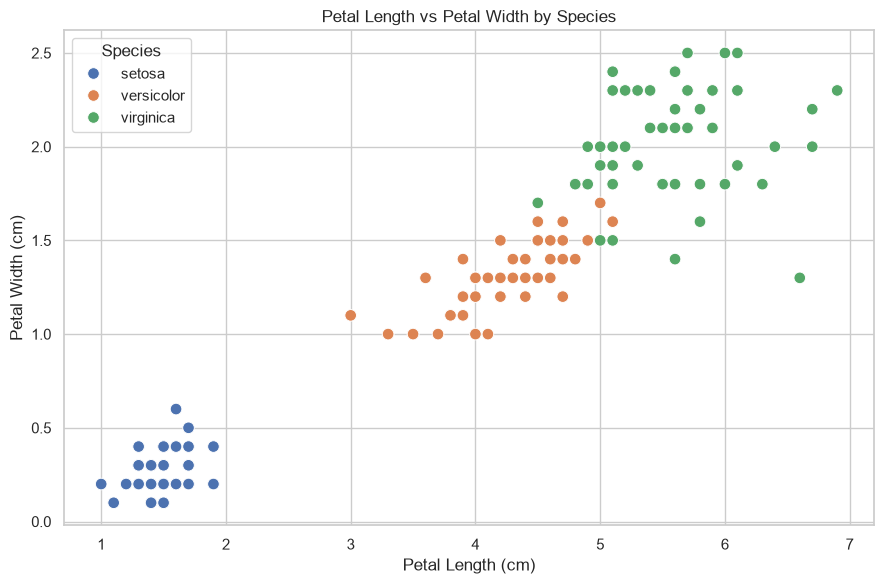

In [13]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=clean_df,
    x="petal_length",
    y="petal_width",
    hue="species",
    s=70
)

plt.title("Petal Length vs Petal Width by Species")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend(title="Species")
plt.tight_layout()
plt.show()


### Insight

Petal length and petal width show a strong positive relationship.

Setosa forms a visually distinct cluster. Versicolor and Virginica show greater overlap, indicating that classification between those two classes may be more challenging than identifying Setosa.


# 18. Visualization 3 — Correlation Heatmap

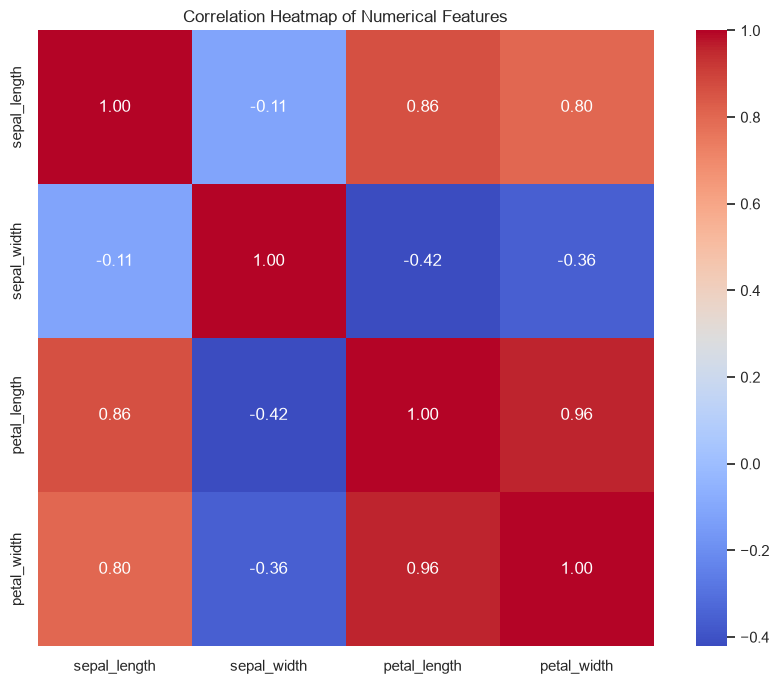

In [14]:
correlation_matrix = clean_df[numeric_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


### Insight

Petal length and petal width have a strong positive correlation. Several other feature pairs also show relationships.

This is useful for feature analysis because highly correlated variables can contain overlapping information. In some modeling approaches, feature correlation can influence interpretation and model behavior.


# 19. Visualization 4 — Pairwise Feature Relationships

In [15]:
# Optional pairwise analysis

# The core Week 1 visualizations above already satisfy the visualization requirement.
# Pairwise relationships are discussed using the correlation matrix and grouped statistics.
print("Pairwise relationships are assessed through the correlation matrix and grouped statistics above.")


Pairwise relationships are assessed through the correlation matrix and grouped statistics above.


### Insight

The pairwise plots reinforce the earlier observation that petal measurements provide strong visual separation among species, while some sepal-based combinations show greater overlap.


# 20. Distribution Analysis

In [16]:
# Optional distribution analysis

distribution_summary = clean_df[numeric_cols].agg(["min", "median", "max"]).T.round(2)
display(distribution_summary)


,min,median,max
sepal_length,4.3,5.8,7.9
sepal_width,2.0,3.0,4.4
petal_length,1.0,4.3,6.9
petal_width,0.1,1.3,2.5


### Interpretation

The distributions provide a quick view of the range and concentration of each numerical measurement. They also help identify whether transformations or scaling might be useful for later machine-learning experiments.


# 21. Grouped Feature Statistics by Species

In [17]:
grouped_stats = (
    clean_df
    .groupby("species", observed=True)[numeric_cols]
    .mean()
    .round(2)
)

display(grouped_stats)


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.42,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.58,2.98,5.56,2.01


### Interpretation

Comparing group means helps explain why some visualizations show separation between classes. In particular, petal measurements differ substantially across species, which is consistent with the scatter plot and correlation analysis.


# 22. Data-Quality Summary

In [18]:
quality_summary = pd.DataFrame({
    "Metric": [
        "Original rows",
        "Working rows",
        "Final cleaned rows",
        "Original columns",
        "Missing cells before cleaning",
        "Missing cells after cleaning",
        "Duplicates before cleaning",
        "Duplicates after cleaning"
    ],
    "Value": [
        len(df),
        len(work_df),
        len(clean_df),
        len(df.columns),
        int(work_df.isna().sum().sum()),
        int(clean_df.isna().sum().sum()),
        int(work_df.duplicated().sum()),
        int(clean_df.duplicated().sum())
    ]
})

display(quality_summary)


,Metric,Value
0,Original rows,150
1,Working rows,153
2,Final cleaned rows,149
3,Original columns,5
4,Missing cells before cleaning,5
5,Missing cells after cleaning,0
6,Duplicates before cleaning,4
7,Duplicates after cleaning,0


# 23. Key Findings

### Data quality

- The source Iris dataset is a small, structured benchmark dataset.
- Five missing numerical values were intentionally simulated.
- Duplicate records were intentionally introduced for cleaning practice.
- Median imputation successfully handled the missing numerical cells.
- Exact duplicates were removed.
- Final validation confirmed zero missing cells and zero duplicate rows.

### Exploratory analysis

- The three species classes are approximately balanced.
- Petal length and petal width have a strong positive relationship.
- Setosa is visually distinct across several feature combinations.
- Versicolor and Virginica show more overlap.
- Numerical features contain useful information for classification.
- Some features are correlated and may contain overlapping information.


# 24. Further Analysis / Future Scope

The cleaned dataset can support several next-stage data-science tasks.

## Machine learning

Potential classification models include:

- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Support Vector Machine

## Evaluation

A future notebook could include:

- Train/test split
- Cross-validation
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Model comparison

## Feature engineering

Potential experiments include:

- Feature scaling
- Standardization
- PCA
- Feature selection
- Interaction analysis

## Reproducibility

For a production project, the data pipeline should also include:

- Versioned source data
- Explicit train/test separation
- Reproducible random seeds where appropriate
- Pipeline objects for transformations
- Automated validation checks


# 25. Export Cleaned Dataset

In [19]:
output_dir = "../data/processed"

os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(
    output_dir,
    "iris_cleaned.csv"
)

clean_df.to_csv(
    output_path,
    index=False
)

print(f"Cleaned dataset saved to: {output_path}")


Cleaned dataset saved to: ../data/processed\iris_cleaned.csv


# 26. GitHub Project Structure

The final repository structure is:

```text
week1-iris-data-analysis/
├── data/
│   ├── raw/
│   │   └── README.md
│   └── processed/
│       └── iris_cleaned.csv
├── notebooks/
│   └── Week_1_Iris_Data_Acquisition_Cleaning_EDA_Complete.ipynb
├── src/
│   └── week1_eda.py
├── reports/
│   └── figures/
│       ├── 01_missing_values.png
│       ├── 02_class_distribution.png
│       ├── 03_petal_scatter.png
│       └── 04_correlation_heatmap.png
├── docs/
│   └── Week_1_Data_Acquisition_Cleaning_EDA_Report.docx
├── requirements.txt
├── PROJECT_INFO.md
├── LICENSE
├── .gitignore
└── README.md
```

**GitHub repository:**  
https://github.com/Vikas-Yadav-6696/week1-iris-data-analysis


# 27. Submission Description

This Week 1 project demonstrates the end-to-end preparation of a public dataset for data-science analysis. The Iris dataset was acquired from the UCI Machine Learning Repository and inspected using Python. To demonstrate practical data-cleaning techniques, controlled missing values and duplicate records were introduced into a working copy of the dataset. Missing numerical values were handled using median imputation, duplicate records were removed, and data types were standardized.

Exploratory data analysis was then performed using summary statistics and visualizations. The analysis includes missing-value comparison, class distribution, petal measurement relationships, correlation analysis, pairwise feature exploration, and distribution analysis. The results show that the classes are approximately balanced, petal measurements have strong relationships, and Setosa is visually distinct while Versicolor and Virginica show more overlap.

The cleaned dataset was validated and exported for future analysis. The project also identifies potential next steps including feature scaling, classification models, cross-validation, PCA, and model evaluation using accuracy, precision, recall, F1-score, and confusion matrices.

The notebook is designed to provide a reproducible record of the Week 1 data acquisition, cleaning, preprocessing, and EDA workflow.


# 28. Final Conclusion

The Week 1 objective was to simulate a realistic data-preparation process using a publicly available dataset.

The completed workflow demonstrates that good data science begins with understanding and validating the data before modeling. Missing values and duplicates were explicitly identified and addressed, the cleaned dataset was validated, and exploratory analysis was used to identify distributions, relationships, and potential modeling features.

The notebook and `src/week1_eda.py` use the same column names, simulated missing-value positions, duplicate-row positions, cleaning logic, and validation checks for reproducibility.

The Iris dataset provides a useful foundation for the next stage of the project, where supervised machine-learning models can be trained and evaluated.

---

**Project status:** Week 1 Data Acquisition, Cleaning, and EDA — Completed

**Author:** Vikas Yadav
